# STAT 790 — Comparing anomaly detection methods (with an application to Healthcare) - Data Analysis
## Exploratory Data Analysis
**Francesco Pecora**

---

This notebook performs initial exploratory data analysis on the Medicare Provider Fraud Detection dataset from Kaggle.

**Dataset source:** https://www.kaggle.com/datasets/rohitrox/healthcare-provider-fraud-detection-analysis

**Goal of this notebook:**
- Understand the structure and shape of each file
- Join the four files into a single claims-level dataset
- Identify continuous vs categorical features (the core mixed-data challenge)
- Visualize distributions, missing values, and fraud/non-fraud splits
- Surface the first signals that motivate our anomaly detection approach

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# Download dataset directly from Kaggle
!pip install kagglehub --quiet

import kagglehub
import os

path = kagglehub.dataset_download("rohitrox/healthcare-provider-fraud-detection-analysis")
print("Downloaded to:", path)

# See what files are there
for f in os.listdir(path):
    print(f)



100%|██████████| 25.4M/25.4M [00:00<00:00, 137MB/s] 

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/versions/1
Test_Beneficiarydata-1542969243754.csv
Train_Outpatientdata-1542865627584.csv
Test_Inpatientdata-1542969243754.csv
Train-1542865627584.csv
Test_Outpatientdata-1542969243754.csv
Train_Inpatientdata-1542865627584.csv
Test-1542969243754.csv
Train_Beneficiarydata-1542865627584.csv


In [ ]:
BASE = path + '/'

PATH_LABELS     = BASE + 'Train-1542865627584.csv'
PATH_BENE       = BASE + 'Train_Beneficiarydata-1542865627584.csv'
PATH_INPATIENT  = BASE + 'Train_Inpatientdata-1542865627584.csv'
PATH_OUTPATIENT = BASE + 'Train_Outpatientdata-1542865627584.csv'

print('Paths set:')
print(PATH_LABELS)

Paths set:
/root/.cache/kagglehub/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/versions/1/Train-1542865627584.csv


---
## 1. Load Each File and Inspect Structure

In [ ]:
df_labels = pd.read_csv(PATH_LABELS)
print(f'Labels shape: {df_labels.shape}')
print(df_labels['PotentialFraud'].value_counts())
df_labels.head()

Labels shape: (5410, 2)
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [ ]:
df_bene = pd.read_csv(PATH_BENE)
print(f'Beneficiary shape: {df_bene.shape}')
print(f'Columns: {df_bene.columns.tolist()}')
df_bene.head()

Beneficiary shape: (138556, 25)
Columns: ['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [ ]:
df_inp = pd.read_csv(PATH_INPATIENT)
print(f'Inpatient shape: {df_inp.shape}')
print(f'Columns: {df_inp.columns.tolist()}')
df_inp.head()

Inpatient shape: (40474, 30)
Columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6']


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_out = pd.read_csv(PATH_OUTPATIENT)
print(f'Outpatient shape: {df_out.shape}')
print(f'Columns: {df_out.columns.tolist()}')
df_out.head()

Outpatient shape: (517737, 27)
Columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode']


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


---
## 2. Join Files into One Claims-Level Dataset

One row per claim, enriched with patient demographics and provider fraud label.

In [ ]:
df_inp['ClaimType'] = 'Inpatient'
df_out['ClaimType'] = 'Outpatient'

df_inp['AdmissionDt'] = pd.to_datetime(df_inp['AdmissionDt'], errors='coerce')
df_inp['DischargeDt'] = pd.to_datetime(df_inp['DischargeDt'], errors='coerce')
df_inp['LengthOfStay'] = (df_inp['DischargeDt'] - df_inp['AdmissionDt']).dt.days

df_claims = pd.concat([df_inp, df_out], axis=0, ignore_index=True)
print(f'Combined claims shape: {df_claims.shape}')

Combined claims shape: (558211, 32)


In [ ]:
df_claims = df_claims.merge(df_bene, on='BeneID', how='left')
print(f'After joining beneficiary data: {df_claims.shape}')

df_claims = df_claims.merge(df_labels, on='Provider', how='left')
print(f'After joining fraud labels: {df_claims.shape}')

df_claims['IsFraud'] = (df_claims['PotentialFraud'] == 'Yes').astype(int)

print(f'\nFraud rate at claim level: {df_claims["IsFraud"].mean():.2%}')
print(df_claims['IsFraud'].value_counts())

After joining beneficiary data: (558211, 56)
After joining fraud labels: (558211, 57)

Fraud rate at claim level: 38.12%
IsFraud
0    345415
1    212796
Name: count, dtype: int64


---
## 3. Feature Inventory — The Mixed-Data Problem

We catalog which features are continuous and which are categorical.

In [ ]:
continuous_features = [
    'InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'LengthOfStay',
    'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt',
    'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
]

categorical_features = [
    'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
    'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
    'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
    'Gender', 'Race', 'State', 'County', 'RenalDiseaseIndicator', 'ClaimType'
]

continuous_features  = [c for c in continuous_features  if c in df_claims.columns]
categorical_features = [c for c in categorical_features if c in df_claims.columns]

print(f'Continuous  ({len(continuous_features)}):  {continuous_features}')
print(f'Categorical ({len(categorical_features)}): {categorical_features}')

Continuous  (9):  ['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'LengthOfStay', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov']
Categorical (14): ['ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'Gender', 'Race', 'State', 'County', 'RenalDiseaseIndicator', 'ClaimType']


In [ ]:
print('Categorical cardinality (unique values) — why classical methods struggle:')
print('-' * 50)
for col in categorical_features:
    print(f'  {col:<35} {df_claims[col].nunique():>6} unique values')

Categorical cardinality (unique values) — why classical methods struggle:
--------------------------------------------------
  ClmDiagnosisCode_1                   10450 unique values
  ClmDiagnosisCode_2                    5300 unique values
  ClmDiagnosisCode_3                    4756 unique values
  ClmDiagnosisCode_4                    4359 unique values
  ClmDiagnosisCode_5                    3970 unique values
  ClmProcedureCode_1                    1117 unique values
  ClmProcedureCode_2                     300 unique values
  ClmProcedureCode_3                     154 unique values
  Gender                                   2 unique values
  Race                                     4 unique values
  State                                   52 unique values
  County                                 314 unique values
  RenalDiseaseIndicator                    2 unique values
  ClaimType                                2 unique values


**Key observation:** Diagnosis and procedure codes have hundreds to thousands of unique values. One-hot encoding explodes the feature space. This is exactly why the 2014 paper needed a manual categorical-to-continuous mapping, and why learned embeddings in our Autoencoder are a cleaner solution.

---
## 4. Missing Value Analysis

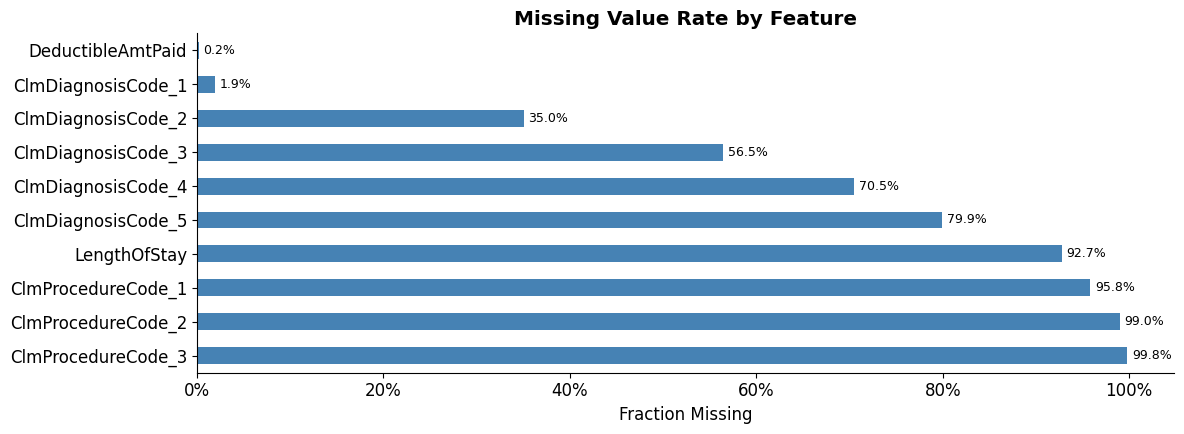

Missing procedure codes are expected: not every claim has a procedure code.


In [ ]:
all_features = continuous_features + categorical_features
miss = df_claims[all_features].isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

if len(miss) == 0:
    print('No missing values in selected features.')
else:
    fig, ax = plt.subplots(figsize=(12, max(4, len(miss) * 0.45)))
    miss.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Fraction Missing')
    ax.set_title('Missing Value Rate by Feature', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for i, v in enumerate(miss):
        ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Missing procedure codes are expected: not every claim has a procedure code.')

---
## 5. Provider-Level View — Fraud vs Legitimate

In [ ]:
provider_agg = df_claims.groupby('Provider').agg(
    TotalClaims          = ('ClaimID', 'count'),
    TotalReimbursed      = ('InscClaimAmtReimbursed', 'sum'),
    AvgReimbursed        = ('InscClaimAmtReimbursed', 'mean'),
    MaxReimbursed        = ('InscClaimAmtReimbursed', 'max'),
    AvgLengthOfStay      = ('LengthOfStay', 'mean'),
    UniquePatients       = ('BeneID', 'nunique'),
    UniqueDiagnosisCodes = ('ClmDiagnosisCode_1', 'nunique'),
    IsFraud              = ('IsFraud', 'first')
).reset_index()

provider_agg['ClaimsPerPatient'] = (
    provider_agg['TotalClaims'] / provider_agg['UniquePatients'].replace(0, np.nan)
)

print(f'Total providers:      {len(provider_agg)}')
print(f'Fraudulent providers: {provider_agg["IsFraud"].sum()} ({provider_agg["IsFraud"].mean():.1%})')
provider_agg.describe().round(2)

Total providers:      5410
Fraudulent providers: 506 (9.4%)


,TotalClaims,TotalReimbursed,AvgReimbursed,MaxReimbursed,AvgLengthOfStay,UniquePatients,UniqueDiagnosisCodes,IsFraud,ClaimsPerPatient
count,5410.00,5410.00,5410.00,5410.00,2092.00,5410.00,5410.00,5410.00,5410.00
mean,103.18,102873.04,1740.68,13014.91,5.67,67.15,81.59,0.09,1.33
std,272.46,268736.68,3484.47,18995.32,2.76,142.75,164.73,0.29,0.54
min,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
25%,10.00,4460.00,232.39,1700.00,4.14,8.00,9.00,0.00,1.00
50%,31.00,19805.00,356.09,3300.00,5.33,25.00,29.00,0.00,1.10
75%,87.00,85565.00,1490.15,17000.00,6.53,65.00,80.00,0.00,1.40
max,8240.00,5996050.00,57000.00,125000.00,35.00,2857.00,3070.00,1.00,10.00


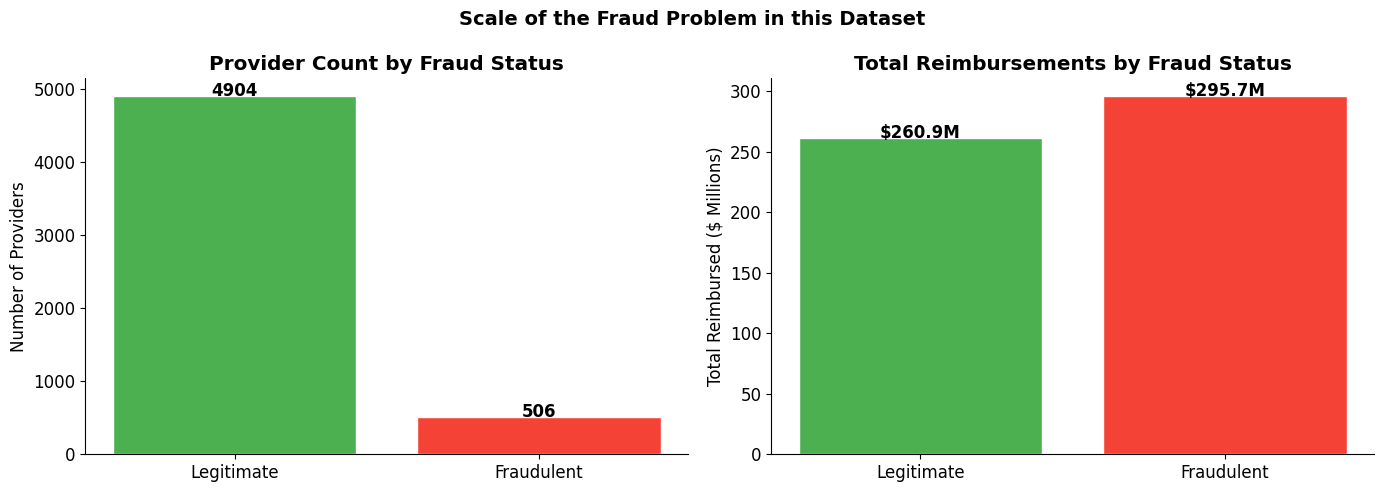

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = provider_agg['IsFraud'].value_counts().sort_index()
axes[0].bar(['Legitimate', 'Fraudulent'], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0].set_title('Provider Count by Fraud Status', fontweight='bold')
axes[0].set_ylabel('Number of Providers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

dollar_by_fraud = provider_agg.groupby('IsFraud')['TotalReimbursed'].sum().sort_index()
axes[1].bar(['Legitimate', 'Fraudulent'], dollar_by_fraud.values / 1e6,
            color=['#4CAF50', '#F44336'], edgecolor='white')
axes[1].set_title('Total Reimbursements by Fraud Status', fontweight='bold')
axes[1].set_ylabel('Total Reimbursed ($ Millions)')
for i, v in enumerate(dollar_by_fraud.values):
    axes[1].text(i, v/1e6 + 0.3, f'${v/1e6:.1f}M', ha='center', fontweight='bold')

plt.suptitle('Scale of the Fraud Problem in this Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fraud_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Diagnosis Code Concentration - do fraudulent providers over-use a small set of codes?

For each provider, count how many claims use their single most common diagnosis code. This is the "concentration" — higher = less variety = more suspicious


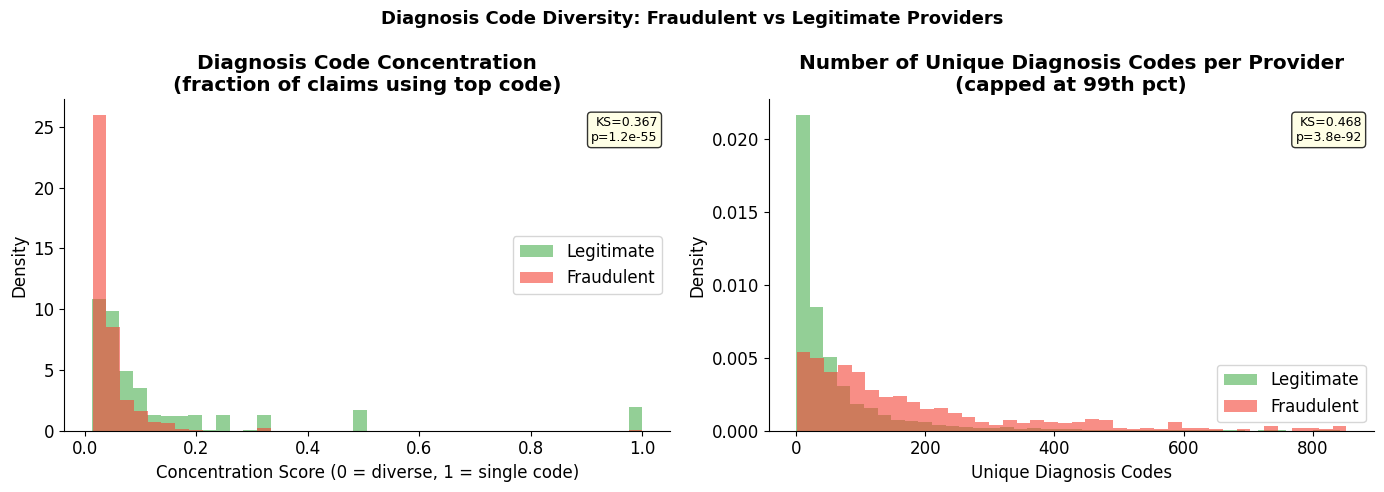

Median concentration — Fraudulent: 0.032 | Legitimate: 0.059
A higher score means more claims billed under the same single diagnosis code.


In [ ]:
def top_code_concentration(group):
    counts = group['ClmDiagnosisCode_1'].value_counts()
    if len(counts) == 0:
        return np.nan
    return counts.iloc[0] / counts.sum()  # fraction of claims using the top code

concentration = df_claims.groupby('Provider').apply(top_code_concentration).reset_index()
concentration.columns = ['Provider', 'DiagnosisConcentration']
provider_agg = provider_agg.merge(concentration, on='Provider', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of concentration scores
fraud_conc = provider_agg[provider_agg['IsFraud'] == 1]['DiagnosisConcentration'].dropna()
legit_conc = provider_agg[provider_agg['IsFraud'] == 0]['DiagnosisConcentration'].dropna()

axes[0].hist(legit_conc, bins=40, alpha=0.6, label='Legitimate', color='#4CAF50', density=True)
axes[0].hist(fraud_conc, bins=40, alpha=0.6, label='Fraudulent', color='#F44336', density=True)
axes[0].set_title('Diagnosis Code Concentration\n(fraction of claims using top code)', fontweight='bold')
axes[0].set_xlabel('Concentration Score (0 = diverse, 1 = single code)')
axes[0].set_ylabel('Density')
axes[0].legend()
ks_stat, ks_p = stats.ks_2samp(legit_conc, fraud_conc)
axes[0].text(0.98, 0.95, f'KS={ks_stat:.3f}\np={ks_p:.1e}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# How many unique diagnosis codes does each provider use?
fraud_unique = provider_agg[provider_agg['IsFraud'] == 1]['UniqueDiagnosisCodes'].dropna()
legit_unique = provider_agg[provider_agg['IsFraud'] == 0]['UniqueDiagnosisCodes'].dropna()
cap = provider_agg['UniqueDiagnosisCodes'].quantile(0.99)

axes[1].hist(legit_unique[legit_unique <= cap], bins=40, alpha=0.6, label='Legitimate', color='#4CAF50', density=True)
axes[1].hist(fraud_unique[fraud_unique <= cap], bins=40, alpha=0.6, label='Fraudulent', color='#F44336', density=True)
axes[1].set_title('Number of Unique Diagnosis Codes per Provider\n(capped at 99th pct)', fontweight='bold')
axes[1].set_xlabel('Unique Diagnosis Codes')
axes[1].set_ylabel('Density')
axes[1].legend()
ks2, ksp2 = stats.ks_2samp(legit_unique.dropna(), fraud_unique.dropna())
axes[1].text(0.98, 0.95, f'KS={ks2:.3f}\np={ksp2:.1e}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Diagnosis Code Diversity: Fraudulent vs Legitimate Providers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagnosis_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median concentration — Fraudulent: {fraud_conc.median():.3f} | Legitimate: {legit_conc.median():.3f}')
print(f'A higher score means more claims billed under the same single diagnosis code.')

---
## 7. Physician Network

Physician network size — fraudulent providers may rely on very few attending physicians

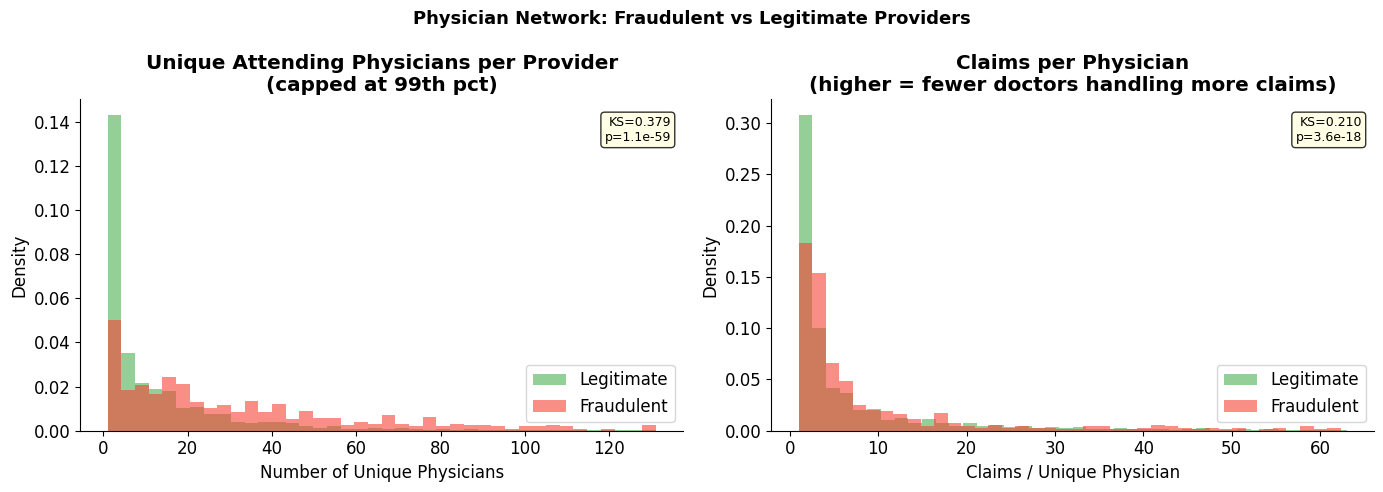

In [ ]:
if 'AttendingPhysician' in df_claims.columns:

    physician_stats = df_claims.groupby('Provider').agg(
        UniquePhysicians=('AttendingPhysician', 'nunique'),
        TotalClaimsForRatio=('ClaimID', 'count')
    ).reset_index()
    physician_stats['ClaimsPerPhysician'] = (
        physician_stats['TotalClaimsForRatio'] / physician_stats['UniquePhysicians'].replace(0, np.nan)
    )
    provider_agg = provider_agg.merge(
        physician_stats[['Provider', 'UniquePhysicians', 'ClaimsPerPhysician']],
        on='Provider', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fraud_phys = provider_agg[provider_agg['IsFraud'] == 1]['UniquePhysicians'].dropna()
    legit_phys = provider_agg[provider_agg['IsFraud'] == 0]['UniquePhysicians'].dropna()
    cap_p = provider_agg['UniquePhysicians'].quantile(0.99)

    axes[0].hist(legit_phys[legit_phys <= cap_p], bins=40, alpha=0.6,
                 label='Legitimate', color='#4CAF50', density=True)
    axes[0].hist(fraud_phys[fraud_phys <= cap_p], bins=40, alpha=0.6,
                 label='Fraudulent', color='#F44336', density=True)
    axes[0].set_title('Unique Attending Physicians per Provider\n(capped at 99th pct)', fontweight='bold')
    axes[0].set_xlabel('Number of Unique Physicians')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    ks_ph, ksp_ph = stats.ks_2samp(legit_phys.dropna(), fraud_phys.dropna())
    axes[0].text(0.98, 0.95, f'KS={ks_ph:.3f}\np={ksp_ph:.1e}',
                 transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    fraud_cpp = provider_agg[provider_agg['IsFraud'] == 1]['ClaimsPerPhysician'].dropna()
    legit_cpp = provider_agg[provider_agg['IsFraud'] == 0]['ClaimsPerPhysician'].dropna()
    cap_cpp = provider_agg['ClaimsPerPhysician'].quantile(0.95)

    axes[1].hist(legit_cpp[legit_cpp <= cap_cpp], bins=40, alpha=0.6,
                 label='Legitimate', color='#4CAF50', density=True)
    axes[1].hist(fraud_cpp[fraud_cpp <= cap_cpp], bins=40, alpha=0.6,
                 label='Fraudulent', color='#F44336', density=True)
    axes[1].set_title('Claims per Physician\n(higher = fewer doctors handling more claims)', fontweight='bold')
    axes[1].set_xlabel('Claims / Unique Physician')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    ks_cp, ksp_cp = stats.ks_2samp(legit_cpp.dropna(), fraud_cpp.dropna())
    axes[1].text(0.98, 0.95, f'KS={ks_cp:.3f}\np={ksp_cp:.1e}',
                 transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    plt.suptitle('Physician Network: Fraudulent vs Legitimate Providers',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('physician_network.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 8. Distribution of Key Features — Fraud vs Legitimate

Visual motivation that anomaly detection can work: fraudulent providers look statistically different.

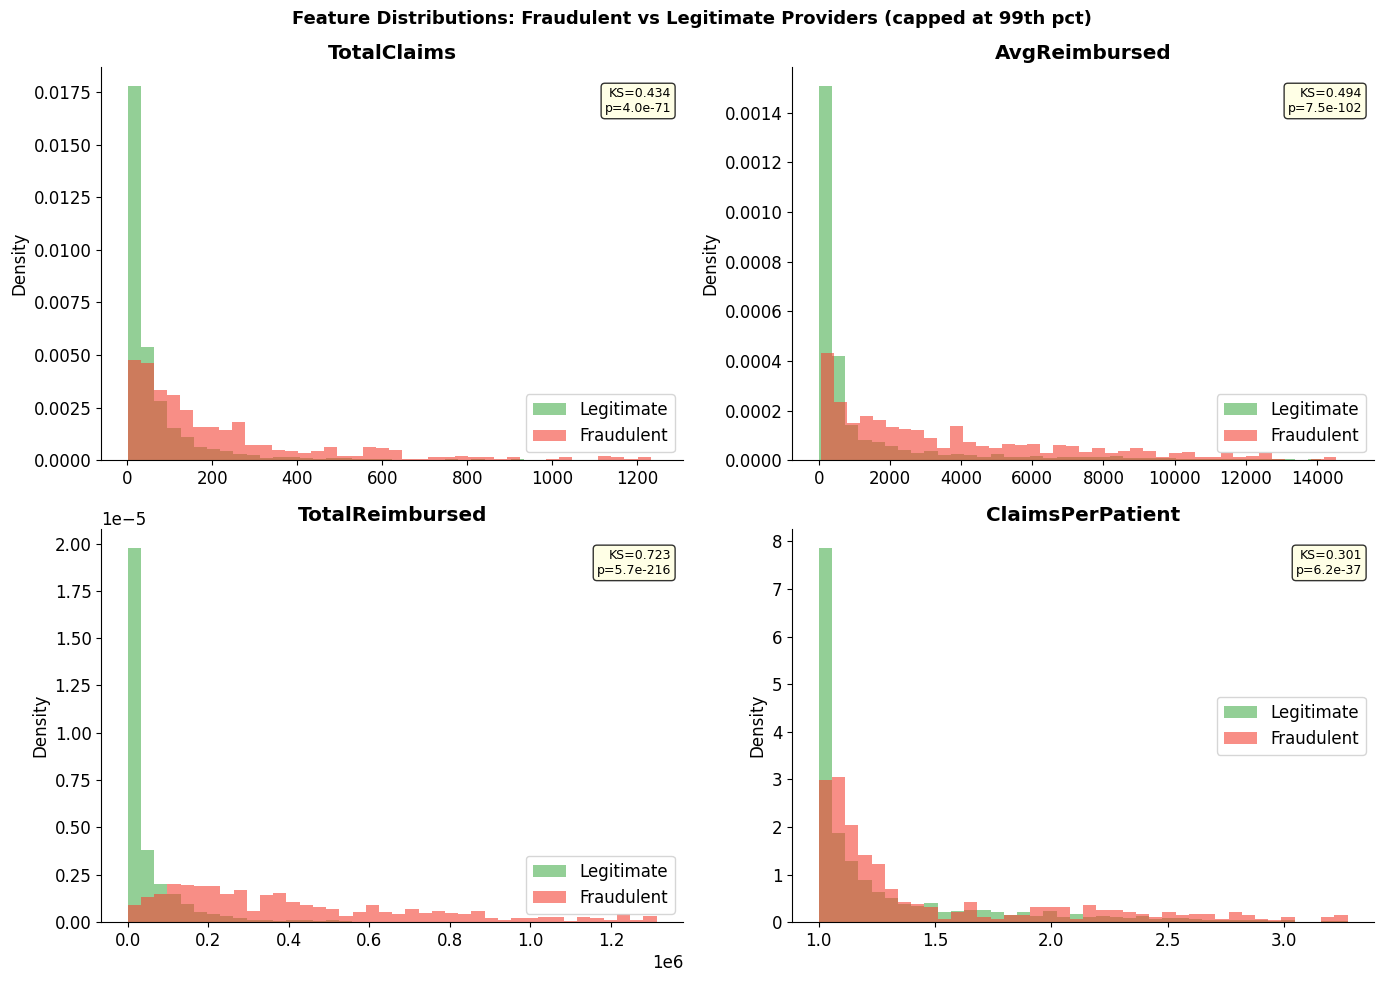

KS statistic closer to 1 = more separable distributions = stronger anomaly signal


In [ ]:
plot_features = ['TotalClaims', 'AvgReimbursed', 'TotalReimbursed', 'ClaimsPerPatient']
plot_features = [f for f in plot_features if f in provider_agg.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    fraud_vals = provider_agg[provider_agg['IsFraud'] == 1][feat].dropna()
    legit_vals = provider_agg[provider_agg['IsFraud'] == 0][feat].dropna()
    cap = provider_agg[feat].quantile(0.99)
    fraud_vals = fraud_vals[fraud_vals <= cap]
    legit_vals = legit_vals[legit_vals <= cap]

    axes[i].hist(legit_vals, bins=40, alpha=0.6, label='Legitimate', color='#4CAF50', density=True)
    axes[i].hist(fraud_vals, bins=40, alpha=0.6, label='Fraudulent', color='#F44336', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    ks_stat, ks_p = stats.ks_2samp(legit_vals, fraud_vals)
    axes[i].text(0.98, 0.95, f'KS={ks_stat:.3f}\np={ks_p:.1e}',
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Feature Distributions: Fraudulent vs Legitimate Providers (capped at 99th pct)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('KS statistic closer to 1 = more separable distributions = stronger anomaly signal')

---
## 9. Speed of Change (Volatility of Effect Size)

Speed of Change — how volatile is each provider's billing behavior month over month? Fraudulent providers may show sudden jumps, not just gradual drift

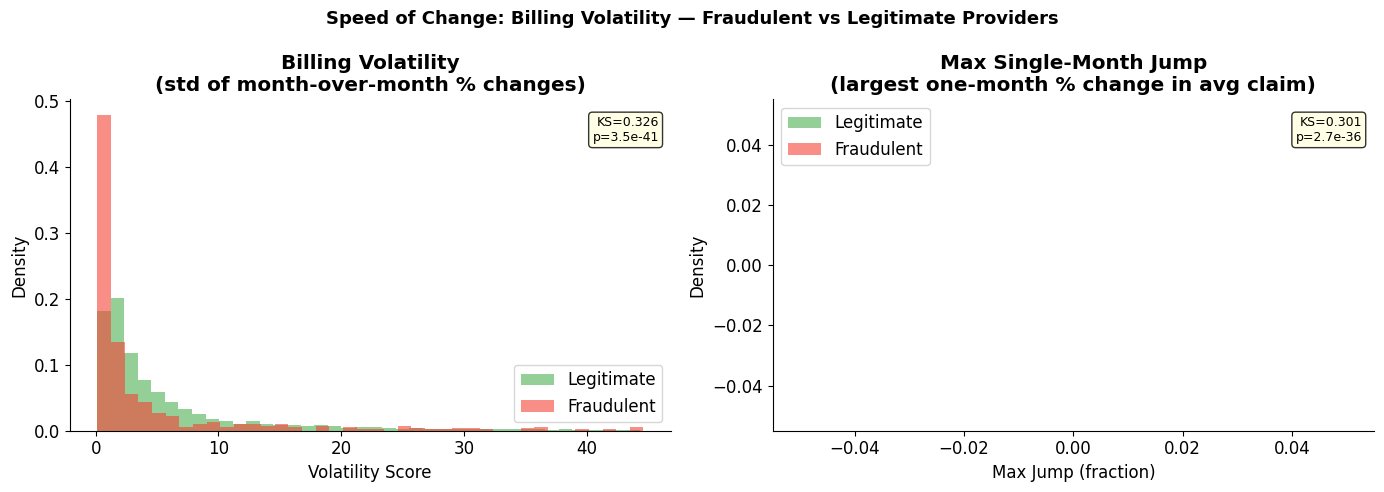

Median volatility  — Fraud: 1.149 | Legit: 3.152
Median max jump    — Fraud: 3.111 | Legit: 9.341


In [ ]:
if 'YearMonth' in df_claims.columns:

    # Compute month-over-month change in average claim amount per provider
    monthly = (
        df_claims.groupby(['Provider', 'YearMonth'])['InscClaimAmtReimbursed']
        .mean()
        .reset_index()
        .sort_values(['Provider', 'YearMonth'])
    )
    monthly['MoM_Change'] = monthly.groupby('Provider')['InscClaimAmtReimbursed'].pct_change()

    # Aggregate to provider level: std of MoM changes = billing volatility
    volatility = (
        monthly.groupby('Provider')['MoM_Change']
        .agg(
            BillingVolatility='std',
            MaxSingleJump=lambda x: x.abs().max(),
            MonthsActive='count'
        )
        .reset_index()
    )

    provider_agg = provider_agg.merge(volatility, on='Provider', how='left')

    # Only keep providers with at least 4 months of data for meaningful volatility
    prov_filtered = provider_agg[provider_agg['MonthsActive'] >= 4].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Billing volatility distribution
    fraud_vol = prov_filtered[prov_filtered['IsFraud'] == 1]['BillingVolatility'].dropna()
    legit_vol = prov_filtered[prov_filtered['IsFraud'] == 0]['BillingVolatility'].dropna()
    cap_vol = prov_filtered['BillingVolatility'].quantile(0.95)

    axes[0].hist(legit_vol[legit_vol <= cap_vol], bins=40, alpha=0.6,
                 label='Legitimate', color='#4CAF50', density=True)
    axes[0].hist(fraud_vol[fraud_vol <= cap_vol], bins=40, alpha=0.6,
                 label='Fraudulent', color='#F44336', density=True)
    axes[0].set_title('Billing Volatility\n(std of month-over-month % changes)', fontweight='bold')
    axes[0].set_xlabel('Volatility Score')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    ks_v, ksp_v = stats.ks_2samp(legit_vol.dropna(), fraud_vol.dropna())
    axes[0].text(0.98, 0.95, f'KS={ks_v:.3f}\np={ksp_v:.1e}',
                 transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    # Max single month jump
    fraud_jump = prov_filtered[prov_filtered['IsFraud'] == 1]['MaxSingleJump'].dropna()
    legit_jump = prov_filtered[prov_filtered['IsFraud'] == 0]['MaxSingleJump'].dropna()
    cap_jump = prov_filtered['MaxSingleJump'].quantile(0.95)

    axes[1].hist(legit_jump[legit_jump <= cap_jump], bins=40, alpha=0.6,
                 label='Legitimate', color='#4CAF50', density=True)
    axes[1].hist(fraud_jump[fraud_jump <= cap_jump], bins=40, alpha=0.6,
                 label='Fraudulent', color='#F44336', density=True)
    axes[1].set_title('Max Single-Month Jump\n(largest one-month % change in avg claim)', fontweight='bold')
    axes[1].set_xlabel('Max Jump (fraction)')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    ks_j, ksp_j = stats.ks_2samp(legit_jump.dropna(), fraud_jump.dropna())
    axes[1].text(0.98, 0.95, f'KS={ks_j:.3f}\np={ksp_j:.1e}',
                 transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    plt.suptitle('Speed of Change: Billing Volatility — Fraudulent vs Legitimate Providers',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('billing_volatility.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Median volatility  — Fraud: {fraud_vol.median():.3f} | Legit: {legit_vol.median():.3f}')
    print(f'Median max jump    — Fraud: {fraud_jump.median():.3f} | Legit: {legit_jump.median():.3f}')

---
## 10. Temporal Drift — Replicating Slavov 2014 Figure 3

The key idea from the baseline paper: compare a provider's behavior to their own historical baseline. Fraudulent providers tend to drift away from their baseline over time.

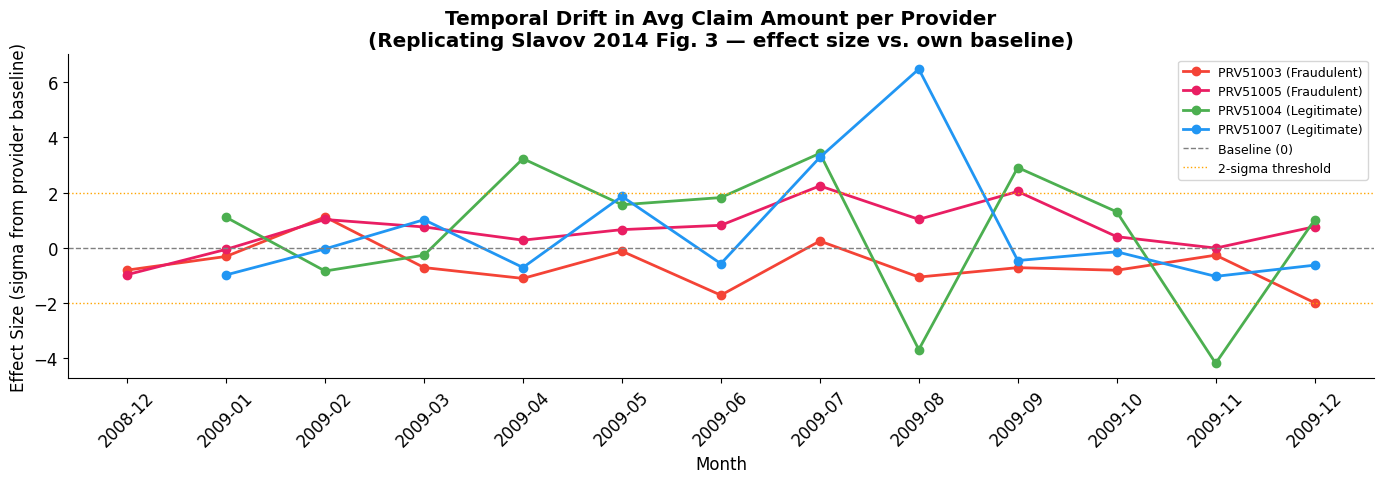

In [ ]:
# Find a date column
date_candidates = ['ClaimStartDt', 'AdmissionDt']
date_col = next((c for c in date_candidates if c in df_claims.columns), None)

if date_col:
    df_claims['ClaimDate'] = pd.to_datetime(df_claims[date_col], errors='coerce')
    df_claims['YearMonth'] = df_claims['ClaimDate'].dt.to_period('M')

    # Providers with enough claims for a time series
    active = df_claims.groupby('Provider')['ClaimID'].count()
    active = active[active >= 30].index

    fraud_provs = provider_agg[
        (provider_agg['IsFraud'] == 1) & (provider_agg['Provider'].isin(active))
    ]['Provider'].head(2).tolist()

    legit_provs = provider_agg[
        (provider_agg['IsFraud'] == 0) & (provider_agg['Provider'].isin(active))
    ]['Provider'].head(2).tolist()

    sample_provs = fraud_provs + legit_provs
    colors = ['#F44336', '#E91E63', '#4CAF50', '#2196F3']
    labels_list = ['Fraudulent', 'Fraudulent', 'Legitimate', 'Legitimate']

    fig, ax = plt.subplots(figsize=(14, 5))

    for prov, color, lbl in zip(sample_provs, colors, labels_list):
        ts = (
            df_claims[df_claims['Provider'] == prov]
            .groupby('YearMonth')['InscClaimAmtReimbursed']
            .mean()
        )
        if len(ts) >= 4:
            baseline_mean = ts.iloc[:3].mean()
            baseline_std  = ts.iloc[:3].std() + 1e-6
            effect        = (ts - baseline_mean) / baseline_std
            ax.plot(
                effect.index.astype(str), effect.values,
                marker='o', label=f'{prov[:10]} ({lbl})',
                color=color, linewidth=2
            )

    ax.axhline(0,  color='gray',   linestyle='--', linewidth=1, label='Baseline (0)')
    ax.axhline(2,  color='orange', linestyle=':',  linewidth=1, label='2-sigma threshold')
    ax.axhline(-2, color='orange', linestyle=':',  linewidth=1)
    ax.set_xlabel('Month')
    ax.set_ylabel('Effect Size (sigma from provider baseline)')
    ax.set_title(
        'Temporal Drift in Avg Claim Amount per Provider\n'
        '(Replicating Slavov 2014 Fig. 3 — effect size vs. own baseline)',
        fontweight='bold'
    )
    ax.legend(fontsize=9)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('temporal_effect_size.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Date column not found yet — check column names from Step 1 and update date_candidates.')

# 11. Feature Correlation Heatmap at Provider Level
Correlation heatmap of provider-level features vs fraud label

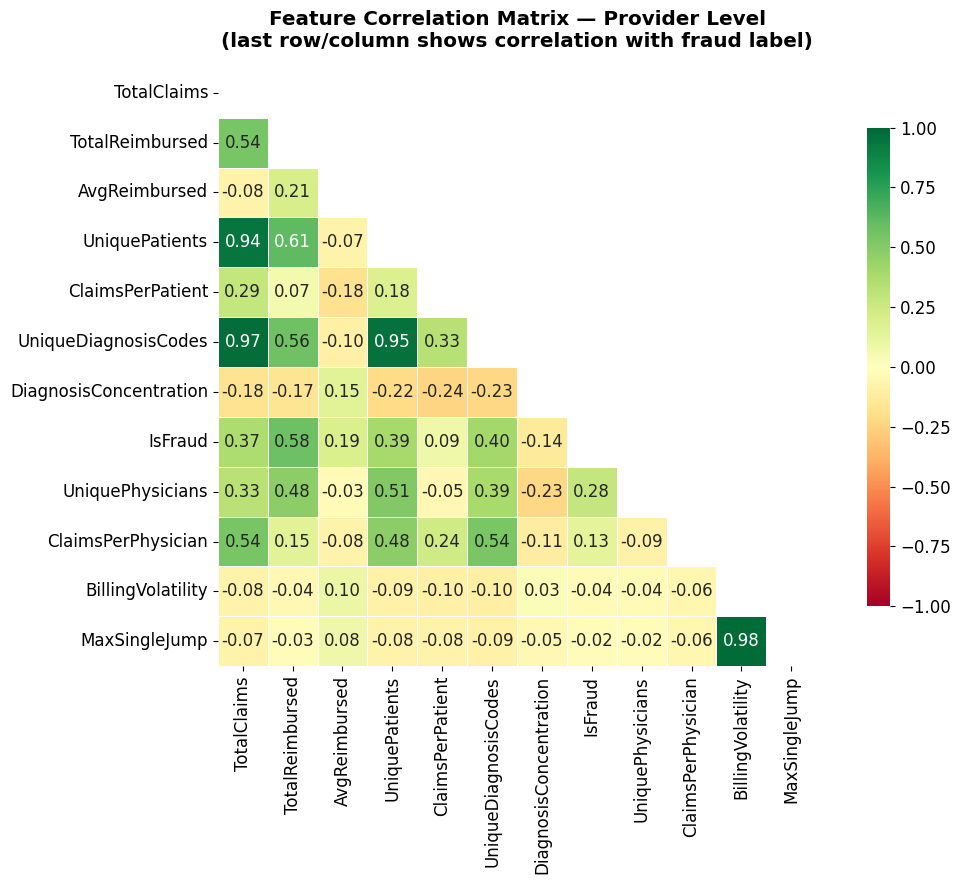

Correlation with fraud label (strongest predictors):
TotalReimbursed           0.576
UniqueDiagnosisCodes      0.400
UniquePatients            0.394
TotalClaims               0.374
UniquePhysicians          0.277
AvgReimbursed             0.194
ClaimsPerPhysician        0.134
ClaimsPerPatient          0.093
MaxSingleJump            -0.024
BillingVolatility        -0.036
DiagnosisConcentration   -0.136


In [ ]:
corr_cols = [
    'TotalClaims', 'TotalReimbursed', 'AvgReimbursed',
    'UniquePatients', 'ClaimsPerPatient', 'UniqueDiagnosisCodes',
    'DiagnosisConcentration', 'IsFraud'
]
# Add optional columns if they exist
for c in ['UniquePhysicians', 'ClaimsPerPhysician', 'BillingVolatility', 'MaxSingleJump']:
    if c in provider_agg.columns:
        corr_cols.append(c)

corr_cols = [c for c in corr_cols if c in provider_agg.columns]
corr_matrix = provider_agg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix — Provider Level\n(last row/column shows correlation with fraud label)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the fraud correlations specifically — most useful for feature selection
fraud_corr = corr_matrix['IsFraud'].drop('IsFraud').sort_values(ascending=False)
print('Correlation with fraud label (strongest predictors):')
print(fraud_corr.round(3).to_string())

---
## 12. Summary Table

In [ ]:
summary_cols = ['TotalClaims', 'TotalReimbursed', 'AvgReimbursed',
                'UniquePatients', 'ClaimsPerPatient']
summary_cols = [c for c in summary_cols if c in provider_agg.columns]

summary = provider_agg.groupby('IsFraud')[summary_cols].median().round(2)
summary.index = ['Legitimate', 'Fraudulent']
print('Median Provider Statistics: Fraudulent vs Legitimate')
print('=' * 60)
print(summary.to_string())

Median Provider Statistics: Fraudulent vs Legitimate
            TotalClaims  TotalReimbursed  AvgReimbursed  UniquePatients  ClaimsPerPatient
Legitimate         27.0          15055.0         332.19            22.0              1.08
Fraudulent        155.5         373450.0        2576.48           117.0              1.19
